In [2]:
# Hwei data

PASSIVE_MARK_TIME = 4 # seconds
Q_CD = [10, 9, 8, 7, 6]
Q_MANA = [80, 90, 100, 110, 120]
W_CD = [18, 17.5, 17, 16.5, 16]
W_MANA = [90, 95, 100, 105, 110]
E_CD = [13, 12.5, 12, 11.5, 11]
E_MANA = [50, 55, 60, 65, 70]
R_CD = [120, 100, 80]
R_MANA = [100, 100, 100]
EQ_CC_DURATION = [1, 1.125, 1.25, 1.375, 1.5]
EW_CC_DURATION = [1.2, 1.4, 1.6, 1.8, 2]
EE_SLOW = [0.4, 0.475, 0.55, 0.625, 0.7]

def base_hp(level: int) -> float:
    return 580 + 109 * level**2

def base_hp_regen(level: int) -> float:
    return 5.5 + 0.55 * level**2

def base_armor(level: int) -> float:
    21 + 4.7 * level**2

def base_mr(level: int) -> float:
    return 30 + 1.3 * level**2

def base_mana(level: int) -> float:
    return 480 + 30 * level**2

def base_mana_regen(level: int) -> float:
    return 7.5 + 0.75 * level**2

def base_ad(level: int) -> float:
    return 54 + 3.3 * level**2

def p_dmg(level: int, ability_power: float) -> float:
    """
    returns amount of passive damage
    """
    return 40 + (285-40)/17*(level-1) + 0.35 * ability_power

def qq_dmg(level: int, ability_power: float, target_max_health: float = 1000) -> float:
    base_dmg = [50, 80, 110, 140, 170]
    max_health_dmg = [0.03, 0.04, 0.05, 0.06, 0.07]
    return base_dmg[level-1] + 0.7 * ability_power + max_health_dmg[level-1] * target_max_health

def qw_dmg(level: int, ability_power: float, target_isolated_or_immobilized: bool = True, target_missing_health_percentage: float = 0.75) -> float:
    base_dmg = [60, 85, 110, 135, 160]
    max_multiplier = [2, 2.375, 2.75, 3.125, 3.5]
    dmg = base_dmg[level-1] + 0.25 * ability_power
    if target_isolated_or_immobilized:
        multiplier = target_missing_health_percentage * max_multiplier[level-1]
        return multiplier * dmg
    return dmg

def qe_dmg(level: int, ability_power: float) -> float:
    """
    assumes hit one initial explosion + all tick damage
    """
    minion_multiplier = 0.6
    monster_multiplier = 1.35
    initial_base_dmg = [20, 35, 50, 65, 80] 
    tick_base_dmg = [5, 8.75, 12.5, 16.25, 20]
    tick_interval = 0.25
    fissure_duration = 2.5
    return initial_base_dmg[level-1] + .3 * ability_power + fissure_duration/tick_interval * (tick_base_dmg[level-1] + .06 * ability_power)

def wq_dmg(level: int, ability_power: float) -> float:
    return 0

def ww_dmg(level: int, ability_power: float) -> float:
    return 0
    
def ww_initial_shield(level: int, ability_power: float, target_ally: bool) -> float:
    base_shield = [50, 70, 90, 110, 130]
    ally_multiplier = 0.85
    return base_shield[level-1] + 0.3 * ability_power

def ww_total_shield(level: int, ability_power: float, target_ally: bool = False) -> float:
    base_shield = [8.33, 11.67, 15, 18.33, 21.67] 
    tick_interval = 0.25
    zone_duration = 3
    ally_multiplier = 0.85
    return ww_intial_shield(level, ability_power, target_ally) + zone_duration/tick_interval * (base_shield[level-1] + 0.05 * ability_power)

def we_dmg(level: int, ability_power: float, aoe: bool = True) -> float:
    minion_monster_multiplier = 0.5
    aoe_multiplier = 0.5
    base_dmg = [20, 30, 40, 50, 60]
    dmg = 3 * base_dmg[level-1] + 0.15 * ability_power
    if aoe:
        return aoe_multiplier * dmg
    return dmg

def we_mana_restore(level: int) -> float:
    base_mana_restore = [45, 50, 55, 60, 65]
    return 3 * base_mana_restore[level-1]

def eq_dmg(level: int, ability_power: float) -> float:
    base_dmg = [70, 100, 150, 190, 230]
    return base_dmg[level-1] + 0.65 * ability_power

def ew_dmg(level: int, ability_power: float) -> float:
    base_dmg = [70, 100, 150, 190, 230]
    return base_dmg[level-1] + 0.65 * ability_power
    
def ee_dmg(level: int, ability_power: float) -> float:
    base_dmg = [70, 100, 150, 190, 230]
    return base_dmg[level-1] + 0.65 * ability_power

def r_dmg(level: int, ability_power: float) -> float:
    duration = 3
    tick_interval = 0.25
    tick_base_dmg = [2.5, 5, 7.5]
    base_dmg = [200, 325, 450]
    return duration/tick_interval * (tick_base_dmg[level-1] + 0.125 * ability_power) + base_dmg[level-1] + 0.8 * ability_power

def cooldown(base_cooldown: float, haste: float) -> float:
    return base_cooldown * 100/(100+haste)

from collections import namedtuple

Spell = namedtuple('Spell', ['dmg_function', 'cd', 'mana'])

SPELLS = {
    'qq': Spell(qq_dmg, Q_CD, Q_MANA),
    'qw': Spell(qw_dmg, Q_CD, Q_MANA),
    'qe': Spell(qe_dmg, Q_CD, Q_MANA),
    'wq': Spell(wq_dmg, W_CD, W_MANA),
    'ww': Spell(ww_dmg, W_CD, W_MANA),
    'we': Spell(we_dmg, W_CD, W_MANA),
    'eq': Spell(eq_dmg, E_CD, E_MANA),
    'ew': Spell(ew_dmg, E_CD, E_MANA),
    'ee': Spell(ee_dmg, E_CD, E_MANA),
    'r': Spell(r_dmg, R_CD, R_MANA),
}

In [44]:
# Item data
from collections import namedtuple

Item = namedtuple('Item', ['ap', 'haste', 'mana', 'hp', 'speed_pct', 'mpen_pct', 'mpen'], defaults=[0, 0, 0, 0, 0, 0, 0])

BLACKFIRE_TORCH = Item(ap=80, haste=20, mana=600)
BLACKFIRE_TORCH_BONUS_AP = 0.04 # per champion, epic monster, and large monster

def blackfire_dps(ability_power: float) -> float:
    """
    lasts 3 seconds 
    """
    tick_interval = 0.5
    tick_base_dmg = 10
    return (tick_base_dmg + 0.01 * ability_power) / tick_interval

SERAPHS_EMBRACE = Item(ap=70, haste=25, mana=1000)

def seraphs_bonus_ap(bonus_mana: float) -> float:
    return 0.02 * bonus_mana

def seraphs_shield(max_hp: float, max_mana: float):
    return 0.3 * max_hp + 0.18 * max_mana

SERAPHS_SHIELD_CD = 90

ACTUALIZER = Item(ap=90, haste=10, mana=300)

ACTUALIZER_CD_SPEED = 0.3
ACTUALIZER_DURATION = 8
ACTUALIZER_ACTIVE_CD = 60

def actualizer_bonus_effect(bonus_mana: float) -> float:
    """
    bonus ability damage, healing, shielding
    """
    return .15 + 0.005 * bonus_mana / 100

COSMIC_DRIVE = Item(ap=70, haste=25, hp=350, speed_pct=0.04)

CRYPTBLOOM = Item(ap=75, haste=20, mpen_pct=0.3)
CRYPTBLOOM_HEAL_CD = 60

def cryptbloom_heal(ability_power: float) -> float:
    return 100 + 0.2 * ability_power

HORIZON_FOCUS = Item(ap=75, haste=25)

HORIZON_FOCUS_CD = 30
HORIZON_FOCUS_DMG_INCREASE = 0.1
HORIZON_FOCUS_DURATION = 6

LIANDRYS = Item(ap=60, hp=300)
LIANDRYS_DMG_INCREASE = 0.06
LIANDRYS_DMG_INCREASE_RAMP_DURATION = 3

def liandrys_dps(target_max_hp: float) -> float:
    tick_interval = 0.5
    return 0.01 * target_max_hp / tick_interval

RABADONS = Item(ap=130)
RABADONS_BONUS_AP = 0.3

SHADOWFLAME = Item(ap=110, mpen=15)
SHADOWFLAME_CRIT_BONUS = 0.2
SHADOWFLAME_CRIT_THRESHOLD = 0.4

VOID_STAFF = Item(ap=95, mpen_pct=0.4)
ZHONYAS = Item(ap=105)

IONIAN_BOOTS = Item(haste=10)
SORC_BOOTS = Item(mpen=12)

In [45]:
# Rune data

LEGENDS_HASTE_MAX_HASTE = 15 # basic abilities only
CUT_DOWN_BONUS_DAMAGE = 0.08
CUT_DOWN_HP_THRESHOLD = 0.6
COUP_DE_GRACE_BONUS_DAMAGE = 0.08
COUP_DE_GRACE_HP_THRESHOLD = 0.4
TRANSCENDENCE_MAX_HASTE = 10
FIRST_STRIKE_BONUS_DAMAGE = 0.07 # true damage
MANAFLOW_BAND_BONUS_MANA = 250
SCORCH_CD = 10

def scorch_dmg(level: int) -> float:
    return 20 + (40-20)/17*(level-1)

def arcane_comet_dmg(level: int, ability_power: float, bonus_ad: float, distance: float) -> float:
    max_distance = 750
    max_distance_bonus = 1
    distance_multiplier = 1 + max_distance_bonus * min(max_distance, distance) / max_distance
    return distance_multiplier * (15 + (100-15)/17*(level-1) + 0.1 * bonus_ad + 0.05 * ability_power)

def arcane_comet_cd(level: int) -> float:
    return 20 - (20-8)/17*(level-1)

<Axes: xlabel='Fight Duration'>

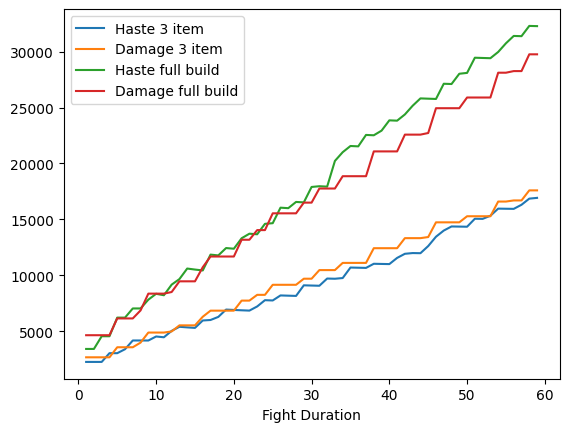

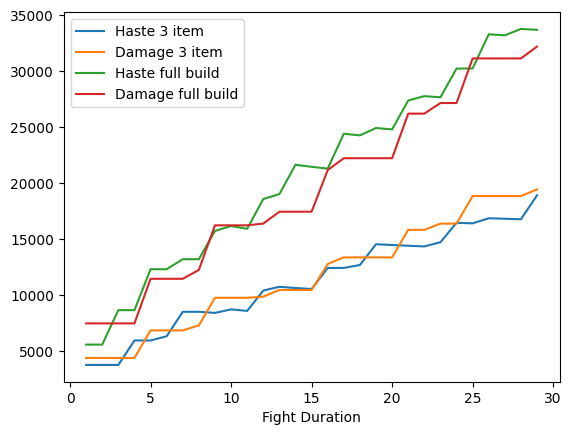

In [49]:
import math

def premitigated_dmg(fight_duration: float, items: list[Item], spells: dict[str, int] = {'qe': 5, 'we': 5, 'ee': 5, 'r': 3}, level=18, number_of_targets=1) -> float:
    """
    :param spells: dictionary of spell cast to spell level
    """
    for spell in spells:
        assert spell in SPELLS.keys(), f"Invalid spell: {spell}"
    assert sum(spells.values()) <= level, "Spell levels cannot exceed champion level"
    assert len(spells) == 4
    # TODO: validate one q, one w, one e, one r
    # assuming legends haste & transcendence
    total_haste = 0
    total_haste += TRANSCENDENCE_MAX_HASTE
    total_haste += sum([item.haste for item in items])
    total_basic_haste = total_haste + LEGENDS_HASTE_MAX_HASTE
    def get_number_of_casts(spell: str):
        base_cooldown = SPELLS[spell].cd[spells[spell]-1]
        total_cooldown = cooldown(base_cooldown, total_haste if spell.startswith('r') else total_basic_haste) 
        # TODO: factor in actualizer
        # assert fight_duration <= ACTUALIZER_DURATION, "TODO: quick hack for assuming quick fight < 8 seconds"
        # if ACTUALIZER in items:
        #     total_cooldown = total_cooldown/(ACTUALIZER_CD_SPEED + 1) # TODO: I think this is how the math works
        cast_count = math.floor(fight_duration/total_cooldown+1)
        return cast_count
    def get_total_mana():
        result = 0
        result += sum([item.mana for item in items])
        # TODO: manaflow band in options
        result += 250
        return result
    # TODO: ap runes
    def get_total_ap():
        result = 0
        result += sum([item.ap for item in items])
        if SERAPHS_EMBRACE in items:
            result += seraphs_bonus_ap(get_total_mana())
        if BLACKFIRE_TORCH in items:
            result += result * BLACKFIRE_TORCH_BONUS_AP * number_of_targets
        if RABADONS in items:
            result += result * RABADONS_BONUS_AP
        return result
    total_ap = get_total_ap()
    result = 0
    # TODO: Actualizer cooldown reduction
    for spell in spells:
        result += get_number_of_casts(spell) * SPELLS[spell].dmg_function(ability_power=total_ap, level=spells[spell])
    # TODO: this assumes 1v1
    passive_procs = math.floor(sum([get_number_of_casts(spell) for spell in spells if not spell.startswith('w')])/2) * number_of_targets
    result += p_dmg(level=level, ability_power=total_ap) * passive_procs
    if ACTUALIZER in items:
        bonus_mana = 0
        bonus_mana += MANAFLOW_BAND_BONUS_MANA
        bonus_mana += sum([item.mana for item in items])
        result += result*actualizer_bonus_effect(bonus_mana) * (min(ACTUALIZER_DURATION,fight_duration)/fight_duration) # TODO: this is a crude estimation
    # TODO: Horizon focus
    # assert fight_duration <= HORIZON_FOCUS_DURATION
    # if HORIZON_FOCUS in items:
    #     result += result*HORIZON_FOCUS_DMG_INCREASE
    # TODO: Liandrys
    return result

# TODO: Post-mitigated damage
target_health = 1000
target_mr = 50

def total_dmg(fight_duration: float, items: list[Item], spells: dict[str, int] = {'qe': 5, 'we': 5, 'ee': 5, 'r': 3}, level=18, number_of_targets=1) -> float:
    effective_mr = target_mr
    # effective_mr -= flat_reduction 
    # effective_mr -= percent_reduction # TODO: bloodletter's curse
    effective_mr -= effective_mr * sum([item.mpen_pct for item in items])
    effective_mr -= sum([item.mpen for item in items])
    return premitigated_dmg(fight_duration, items, spells, level, number_of_targets) * ((100/(100+effective_mr)) if effective_mr >= 0 else (2 - 100/(100-effective_mr)))


# duration = ACTUALIZER_DURATION
# result = total_dmg(duration, items=[BLACKFIRE_TORCH, SERAPHS_EMBRACE, ACTUALIZER, COSMIC_DRIVE, CRYPTBLOOM, HORIZON_FOCUS, IONIAN_BOOTS])
# print(result)
# result = total_dmg(duration, items=[BLACKFIRE_TORCH, SERAPHS_EMBRACE, ACTUALIZER, RABADONS, CRYPTBLOOM, HORIZON_FOCUS, IONIAN_BOOTS])
# print(result)

import pandas as pd

item_set1 = [BLACKFIRE_TORCH, SERAPHS_EMBRACE, ACTUALIZER, IONIAN_BOOTS]
item_set2 = [BLACKFIRE_TORCH, SHADOWFLAME, RABADONS, SORC_BOOTS]
# item_set3 = [BLACKFIRE_TORCH, LIANDRYS, SHADOWFLAME, SORC_BOOTS] # Most common (mid) build on lolalytics

item_set3 = [BLACKFIRE_TORCH, SERAPHS_EMBRACE, ACTUALIZER, COSMIC_DRIVE, HORIZON_FOCUS, CRYPTBLOOM, IONIAN_BOOTS]
item_set4 = [BLACKFIRE_TORCH, SHADOWFLAME, RABADONS, LIANDRYS, VOID_STAFF, ZHONYAS, SORC_BOOTS]
number_of_targets=1
series = pd.DataFrame({
    "Fight Duration": range(1, 60),
})
series["Haste 3 item"] = series.apply(lambda x: total_dmg(x["Fight Duration"], item_set1, number_of_targets=number_of_targets), axis=1)
series["Damage 3 item"] = series.apply(lambda x: total_dmg(x["Fight Duration"], item_set2, number_of_targets=number_of_targets), axis=1)
series["Haste full build"] = series.apply(lambda x: total_dmg(x["Fight Duration"], item_set3, number_of_targets=number_of_targets), axis=1)
series["Damage full build"] = series.apply(lambda x: total_dmg(x["Fight Duration"], item_set4, number_of_targets=number_of_targets), axis=1)

series.plot(x="Fight Duration", y=["Haste 3 item", "Damage 3 item", "Haste full build", "Damage full build"])


number_of_targets=5
series = pd.DataFrame({
    "Fight Duration": range(1, 30),
})
series["Haste 3 item"] = series.apply(lambda x: total_dmg(x["Fight Duration"], item_set1, number_of_targets=number_of_targets), axis=1)
series["Damage 3 item"] = series.apply(lambda x: total_dmg(x["Fight Duration"], item_set2, number_of_targets=number_of_targets), axis=1)
series["Haste full build"] = series.apply(lambda x: total_dmg(x["Fight Duration"], item_set3, number_of_targets=number_of_targets), axis=1)
series["Damage full build"] = series.apply(lambda x: total_dmg(x["Fight Duration"], item_set4, number_of_targets=number_of_targets), axis=1)

series.plot(x="Fight Duration", y=["Haste 3 item", "Damage 3 item", "Haste full build", "Damage full build"])
